In [ ]:
import os
import sys
import pandas as pd
import argparse
import warnings
from utils import *
from torch import nn
import copy
from tqdm import tqdm
import random 
from data_loader import *
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
import numpy as np
from http import HTTPStatus
import dashscope
from dashscope import Generation
import json
# import openai
from openai import OpenAI
from deepseek import DeepSeekClient
import os
from train import *
from model import GurobiPowerScheduler
from together import Together
import pickle
warnings.filterwarnings("ignore")


dashscope.api_key = 'Your key'
DEEPSEEK_API_KEY = 'Your key'
OPENAI_API_KEY ='Your key'
LLAMA_API_KEY='Your key'

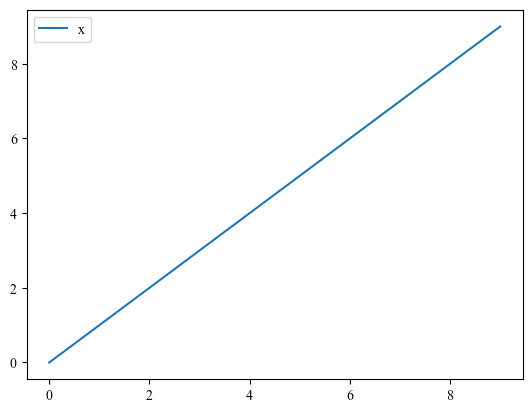

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
import matplotlib as mpl
from matplotlib import font_manager as fm

font_path = '../../times.ttf' # 或绝对路径 '/home/me/fonts/times.ttf'
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
font_name = prop.get_name()

mpl.rcParams['font.family'] = font_name
plt.plot(range(10),range(10),label='x')
plt.legend()

In [4]:
parser_train = argparse.ArgumentParser()
parser_train.add_argument('--seq_len', type=int, default=24*7)
parser_train.add_argument('--pred_len', type=int, default=24)
parser_train.add_argument('--label_len', type=int, default=0)
parser_train.add_argument('--train_length', type=int, default=17376)
parser_train.add_argument('--target', type=str, default='target')
parser_train.add_argument('--scale', type=bool, default=True)
parser_train.add_argument('--inverse', type=bool, default=True)
parser_train.add_argument('--num_epochs', type=int, default=1000)
parser_train.add_argument('--mode', type=str, default='seq2seq')
parser_train.add_argument('--quantiles', type=list, default=[0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95])
parser_train.add_argument('--lr', type=float, default=1e-3)
parser_train.add_argument('--patience', type=int, default=5)
parser_train.add_argument('--hidden_layers', type=list, default=[128,128,128])
parser_train.add_argument('--e2e_num_epochs', type=int, default=5)
parser_train.add_argument('--e2e_ft_lr', type=float, default=1e-6)
parser_train.add_argument('--e2e_lr', type=float, default=1e-7)#1e-7
parser_train.add_argument('--ft_lr', type=float, default=1e-4)
parser_train.add_argument('--batch_size', type=int, default=16)
parser_train.add_argument('--device', type=str, default='cuda:0' if torch.cuda.is_available() else 'cpu')
parser_train.add_argument('--epsion_p', type=float, default=1e1)
parser_train.add_argument('--epsion_l', type=float, default=1e1)
parser_train.add_argument('--metric_list', type=list, default=['pinball_loss','winkler_score_0.1','MAE','RMSE'])


parser_train.add_argument('--N_g', type=int, default=3)
parser_train.add_argument('--T', type=int, default=24)
parser_train.add_argument('--N', type=int, default=25)
parser_train.add_argument('--x_max', type=int, default=[1500,1800,2000])
parser_train.add_argument('--x_min', type=int, default=[0,0,0])
parser_train.add_argument('--z_pos_max', type=list, default=[500,700,800])
parser_train.add_argument('--z_neg_max', type=list, default=[500,700,800])
parser_train.add_argument('--z_pos_min', type=int, default=0)
parser_train.add_argument('--z_neg_min', type=int, default=0)
parser_train.add_argument('--r_neg', type=int, default=[800,800,500])
parser_train.add_argument('--r_pos', type=int, default=[800,800,500])
parser_train.add_argument('--alpha', type=list, default=[0.03 for i in range(24)]+[0.028 for i in range(24)]+[0.032 for i in range(24)])
parser_train.add_argument('--alpha_pos', type=list, default=[0.02 for i in range(24)]+[0.018 for i in range(24)]+[0.022 for i in range(24)])
parser_train.add_argument('--alpha_neg', type=list, default=[0.01 for i in range(24)]+[0.009 for i in range(24)]+[0.011 for i in range(24)])

parser_train.add_argument('--rho_z_pos', type=list, default=[0.05 for i in range(24)]+[0.045 for i in range(24)]+[0.055 for i in range(24)])
parser_train.add_argument('--rho_z_neg', type=list, default=[0.01 for i in range(24)]+[0.008 for i in range(24)]+[0.012 for i in range(24)])

parser_train.add_argument('--rho_r_pos', type=list, default=[0.1 for i in range(24)])
parser_train.add_argument('--rho_r_neg', type=list, default=[0.05 for i in range(24)])

parser_train.add_argument('--price_ratio_large', type=float, default=2.5)
parser_train.add_argument('--price_ratio_small', type=float, default=0.8)
parser_train.add_argument('--flag_dynamic_price', type=bool, default=False)
parser_train.add_argument('--flag_dynamic_mode', type=int, default=0)
parser_train.add_argument('--upper_quantiles', type=float, default=0.95)
parser_train.add_argument('--lower_quantiles', type=float, default=0.05)
parser_train.add_argument('--epsion', type=float, default=1)
parser_train.add_argument('--LLM_type', type=str, default='Llama') #'euclidean' 'manhattan'
args = parser_train.parse_args(args=[])

In [5]:
train_load_data,train_load_loader=get_load_data(args,flag='train')
val_load_data,val_load_loader=get_load_data(args,flag='val')
test_load_data,test_load_loader=get_load_data(args,flag='test')

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

(26113, 219)
(26113, 219)
(26113, 219)


In [6]:
input_size=train_load_data.X.shape[-1]
output_size=24
set_seed(42)

layer_sizes=[128,128,128]
model_load=ANN(input_size=input_size, layer_sizes=layer_sizes, output_size=output_size).to(device)
train(args, model_load, train_load_loader, val_load_loader,dir_best_model='../Model/best_ann_load.pt')

Using device: cuda:0
Epoch [1/1000] Train Loss: 0.0588 Val Loss: 0.0193
Epoch [2/1000] Train Loss: 0.0090 Val Loss: 0.0075
Epoch [3/1000] Train Loss: 0.0059 Val Loss: 0.0069
Epoch [4/1000] Train Loss: 0.0054 Val Loss: 0.0066
Epoch [5/1000] Train Loss: 0.0053 Val Loss: 0.0064
Epoch [6/1000] Train Loss: 0.0049 Val Loss: 0.0060
Epoch [7/1000] Train Loss: 0.0049 Val Loss: 0.0057
Epoch [8/1000] Train Loss: 0.0052 Val Loss: 0.0055
Epoch [9/1000] Train Loss: 0.0043 Val Loss: 0.0052
Epoch [10/1000] Train Loss: 0.0041 Val Loss: 0.0048
Epoch [11/1000] Train Loss: 0.0038 Val Loss: 0.0046
Epoch [12/1000] Train Loss: 0.0037 Val Loss: 0.0043
Epoch [13/1000] Train Loss: 0.0034 Val Loss: 0.0041
Epoch [14/1000] Train Loss: 0.0036 Val Loss: 0.0038
Epoch [15/1000] Train Loss: 0.0034 Val Loss: 0.0036
Epoch [16/1000] Train Loss: 0.0028 Val Loss: 0.0038
Epoch [17/1000] Train Loss: 0.0029 Val Loss: 0.0035
Epoch [18/1000] Train Loss: 0.0029 Val Loss: 0.0032
Epoch [19/1000] Train Loss: 0.0026 Val Loss: 0.0029


In [7]:
test_input=torch.tensor(test_load_data.X).to(device).float()
test_pred_nor=model_load(test_input).detach().cpu().numpy()
test_pred = train_load_data.inverse_transform(test_pred_nor)
test_actual_nor=test_load_data.y#.reshape(-1,1)
test_actual = train_load_data.inverse_transform(test_actual_nor)

print(MAE(test_pred,test_actual),RMSE(test_pred,test_actual),MAPE(test_pred,test_actual))

108.93030977797234 139.44284533957995 0.029723884245756324


In [8]:
val_input=torch.tensor(val_load_data.X).to(device).float()
val_pred_nor=model_load(val_input).detach().cpu().numpy()
val_pred = train_load_data.inverse_transform(val_pred_nor)
val_actual_nor=val_load_data.y#.reshape(-1,1)
val_actual = train_load_data.inverse_transform(val_actual_nor)

print(MAE(val_pred,val_actual),RMSE(val_pred,val_actual),MAPE(val_pred,val_actual))

93.48481050557758 131.1995755421263 0.027242015189285804


In [9]:
from utils import *
combined_train_data,combined_train_loader,combined_val_data,combined_val_loader,combined_test_data,combined_test_loader,combined_fine_tune_data,combined_fine_tuned_loader = obtain_price(args,train_load_data,val_load_data,test_load_data)

determinisitic_opt_layer = Determinisitic_layer(args)
intra_opt_layer = Intra_schdule_layer(args)

model_org_deterministic =  Combined_deterministic(determinisitic_opt_layer,intra_opt_layer, copy.deepcopy(model_load)).to(device)
model_org_deterministic.to(device)

Combined_deterministic(
  (model_load): ANN(
    (layers): ModuleList(
      (0): Linear(in_features=195, out_features=128, bias=True)
      (1-2): 2 x Linear(in_features=128, out_features=128, bias=True)
      (3): Linear(in_features=128, out_features=24, bias=True)
    )
  )
  (Deterministic_layer): CvxpyLayer()
  (Intra_schdule_layer): CvxpyLayer()
)

In [10]:
from E2E import E2E_test_ideal,E2E_test

In [11]:
# temp_act=torch.concatenate(actual_load_org, axis=0).detach().cpu().numpy()
# temp_for=torch.concatenate(forecasts_load_org, axis=0).detach().cpu().numpy()
# MAPE(temp_for, temp_act)

In [12]:
from E2E import E2E_test_ideal

_,_,cost_list_ideal,_,_=E2E_test_ideal(args, model_org_deterministic, combined_test_loader, train_load_data.scaler_y, time_flag=True)
_,_,cost_list_train_ideal,_,_=E2E_test_ideal(args, model_org_deterministic, combined_train_loader, train_load_data.scaler_y, time_flag=True)
_,_,cost_list_val_ideal,_,_=E2E_test_ideal(args, model_org_deterministic, combined_val_loader, train_load_data.scaler_y, time_flag=True)
solution_list_intra_org,solution_list_intra_org, cost_list_org,forecasts_load_org,actual_load_org=E2E_test(args, model_org_deterministic, combined_test_loader, train_load_data.scaler_y, time_flag=False)
solution_list_val,solution_list_val, cost_list_val,forecasts_load_val,actual_load_val=E2E_test(args, model_org_deterministic, combined_val_loader, train_load_data.scaler_y, time_flag=False)
solution_list_train,solution_list_train, cost_list_train,forecasts_load_train,actual_load_train=E2E_test(args, model_org_deterministic, combined_train_loader, train_load_data.scaler_y, time_flag=False)

_,_, cost_list_test,forecasts_load_test,actual_load_test=E2E_test(args, model_org_deterministic, combined_test_loader, train_load_data.scaler_y, time_flag=False)
_,_, cost_list_val,forecasts_load_val,actual_load_val=E2E_test(args, model_org_deterministic, combined_val_loader, train_load_data.scaler_y, time_flag=False)
_,_, cost_list_train,forecasts_load_train,actual_load_train=E2E_test(args, model_org_deterministic, combined_train_loader, train_load_data.scaler_y, time_flag=False)

--------------Load--------------
MAPE 0.026703148663574906 MAE 93.11985823148419 RMSE 124.3531393718805


Test Objective: 2392.1897411970685
--------------Load--------------
MAPE 0.023070598064098745 MAE 85.40701572073712 RMSE 102.4584223431196
Test Objective: 2650.9600324968183
--------------Load--------------
MAPE 0.028041817869858335 MAE 107.7761948995647 RMSE 130.970316216041
Test Objective: 2622.0246027563635
--------------Load--------------
MAPE 0.04184621381587809 MAE 153.14167904401464 RMSE 189.61928660631418
Test Objective: 2452.369167975787
--------------Load--------------
MAPE 0.024360145229701115 MAE 82.86548286676407 RMSE 101.95028955516986
Test Objective: 2364.880033902491
No more data to read.
--------------Load--------------
MAPE 0.03017017227816522 MAE 105.49986951062844 RMSE 140.93685249787808
Test Objective: 2329.353277041002
--------------Load--------------
MAPE 0.024123830241557388 MAE 80.48570971397567 RMSE 106.08343860868976
Test Objective: 2243.9930253559232
--------------Load--------------
MAPE 0.024338170752334676 MAE 81.1763662226925 RMSE 99.91271889690967
Test O

In [13]:
X_test=train_load_data.inverse_transform_X(test_load_data.X)
X_train=train_load_data.inverse_transform_X(train_load_data.X)
X_val=train_load_data.inverse_transform_X(val_load_data.X)

In [14]:

model_e2e_deterministic=E2E_train(args, model_org_deterministic, combined_train_loader, combined_test_loader,train_load_data.scaler_y)
_,_, cost_list_test_optnet,forecasts_load_test_optnet,actual_load_test_optnet=E2E_test(args, model_e2e_deterministic, combined_test_loader, train_load_data.scaler_y, time_flag=True)
_,_,cost_list_val_optnet,forecasts_load_val_optnet,actual_load_val_optnet=E2E_test(args, model_e2e_deterministic, combined_val_loader, train_load_data.scaler_y, time_flag=True)
_,_,cost_list_train_optnet,forecasts_load_train_optnet,actual_load_train_optnet=E2E_test(args, model_e2e_deterministic, combined_train_loader, train_load_data.scaler_y, time_flag=True)

e2e epoch: 0


e2e epoch: 1
e2e epoch: 2
torch.Size([7, 195])
--------------Load--------------
MAPE 0.02694252988914716 MAE 94.01190064714423 RMSE 124.55181906400463
Test Objective: 2711.1049990832707
torch.Size([7, 195])
--------------Load--------------
MAPE 0.020510732613577602 MAE 77.74116866556662 RMSE 95.31364092613775
Test Objective: 2950.6909936780385
torch.Size([7, 195])
--------------Load--------------
MAPE 0.030831106980249906 MAE 119.61111125802356 RMSE 145.6514126214679
Test Objective: 2922.7571717521864
torch.Size([7, 195])
--------------Load--------------
MAPE 0.04413788351336506 MAE 163.3468582583148 RMSE 201.15168399118633
Test Objective: 2870.5223173789614
torch.Size([1, 195])
--------------Load--------------
MAPE 0.030722076420563158 MAE 104.40986804043253 RMSE 120.2825094279665
Test Objective: 2580.4118367796677
No more data to read.
torch.Size([16, 195])
--------------Load--------------
MAPE 0.02893573644044121 MAE 101.48838403717188 RMSE 129.94838936805152
Test Objective: 2684.55

In [15]:
from model import *
from E2E import *

In [16]:
cost_list_test_insert=[cost_list_test[i]-cost_list_ideal[i] for i in range(len(cost_list_test))]
actual_load_test_insert=[train_load_data.scaler_y.transform(tensor.detach().cpu().numpy().reshape(1,-1)).tolist()[0] for tensor in actual_load_test]
forecasts_load_test_insert=[train_load_data.scaler_y.transform(tensor.detach().cpu().numpy().reshape(1,-1)).tolist()[0] for tensor in forecasts_load_test]

cost_list_test_insert_optnet=[cost_list_test_optnet[i]-cost_list_ideal[i] for i in range(len(cost_list_test_optnet))]
actual_load_test_insert_optnet=[train_load_data.scaler_y.transform(tensor.detach().cpu().numpy().reshape(1,-1)).tolist()[0] for tensor in actual_load_test_optnet ]
forecasts_load_test_insert_optnet=[train_load_data.scaler_y.transform(tensor.detach().cpu().numpy().reshape(1,-1)).tolist()[0] for tensor in forecasts_load_test_optnet]

cost_list_train_insert=[cost_list_train[i]-cost_list_train_ideal[i] for i in range(len(cost_list_train))]
actual_load_train_insert=[train_load_data.scaler_y.transform(tensor.detach().cpu().numpy().reshape(1,-1)).tolist()[0] for tensor in actual_load_train]
forecasts_load_train_insert=[train_load_data.scaler_y.transform(tensor.detach().cpu().numpy().reshape(1,-1)).tolist()[0] for tensor in forecasts_load_train]

cost_list_train_insert_optnet=[cost_list_train_optnet[i]-cost_list_train_ideal[i] for i in range(len(cost_list_train_optnet))]
actual_load_train_insert_optnet=[train_load_data.scaler_y.transform(tensor.detach().cpu().numpy().reshape(1,-1)).tolist()[0] for tensor in actual_load_train_optnet]
forecasts_load_train_insert_optnet=[train_load_data.scaler_y.transform(tensor.detach().cpu().numpy().reshape(1,-1)).tolist()[0] for tensor in forecasts_load_train_optnet]

cost_list_val_insert=[cost_list_val[i]-cost_list_val_ideal[i] for i in range(len(cost_list_val))]
actual_load_val_insert=[train_load_data.scaler_y.transform(tensor.detach().cpu().numpy().reshape(1,-1)).tolist()[0] for tensor in actual_load_val]
forecasts_load_val_insert=[train_load_data.scaler_y.transform(tensor.detach().cpu().numpy().reshape(1,-1)).tolist()[0] for tensor in forecasts_load_val]    

cost_list_val_insert_optnet=[cost_list_val_optnet[i]-cost_list_val_ideal[i] for i in range(len(cost_list_val_optnet))]
actual_load_val_insert_optnet=[train_load_data.scaler_y.transform(tensor.detach().cpu().numpy().reshape(1,-1)).tolist()[0] for tensor in actual_load_val_optnet ]
forecasts_load_val_insert_optnet=[train_load_data.scaler_y.transform(tensor.detach().cpu().numpy().reshape(1,-1)).tolist()[0] for tensor in forecasts_load_val_optnet]


db_train = CurveDictDB()
cur_id_start = max(db_train.data.keys(), default=0) + 1
for i, (cost, load, fine_tuned_load, actual_load) in enumerate(zip(cost_list_train_insert, forecasts_load_train_insert,forecasts_load_train_insert_optnet, actual_load_train_insert)):
    record = {
        'id': cur_id_start + i,
        'flag': 0,
        'prompt': '',
        'load': load,
        'fine_tuned_load': fine_tuned_load,
        'cost': cost,
        'actual_load': actual_load,
        'cost_reduction': 0, # 1代表成本比fine tune前低
    }
    db_train.insert(record)

db_val = CurveDictDB()
cur_id_start_val = max(db_val.data.keys(), default=0) + 1
for i, (cost, load, fine_tuned_load, actual_load) in enumerate(zip(cost_list_val_insert, forecasts_load_val_insert, forecasts_load_val_insert_optnet, actual_load_val_insert)):
    record = {
        'id': cur_id_start_val + i,
        'flag': 0,
        'prompt': '',
        'load': load,
        'fine_tuned_load': fine_tuned_load,
        'cost': cost,
        'actual_load': actual_load,
        'cost_reduction': 0,
    }
    db_val.insert(record)


In [17]:
def generate_prompt_sys(args,data):
    # Return English prompt
    prompt = (
        f"You are a power dispatch expert. There are {args.N_g} generating units:\n"
        f"Unit 1: {args.x_min}~{args.x_max} MW, "
        f"Unit 2: {args.x_min}~{args.x_max} MW, "
        f"Unit 3: {args.x_min}~{args.x_max} MW.\n"
        f"Unit 1 generation cost: {args.alpha[0:args.T]}*x RMB/kWh, "
        f"Unit 2 generation cost: {args.alpha[args.T:2*args.T]}*x RMB/kWh, "
        f"Unit 3 generation cost: {args.alpha[args.T*2:args.T*3]}*x RMB/kWh.\n"
        f"Unit 1 positive reserve limit: {args.rho_z_pos[0:args.T]} RMB/kWh, "
        f"Unit 1 negative reserve limit: {args.rho_z_neg[0:args.T]} RMB/kWh.\n"
        f"Unit 2 positive reserve limit: {args.rho_z_pos[args.T:2*args.T]} RMB/kWh, "
        f"Unit 2 negative reserve limit: {args.rho_z_neg[args.T:2*args.T]} RMB/kWh.\n"
        f"Unit 3 positive reserve limit: {args.rho_z_pos[args.T*2:args.T*3]} RMB/kWh, "
        f"Unit 3 negative reserve limit: {args.rho_z_neg[args.T*2:args.T*3]} RMB/kWh.\n"   
    )
    
    return prompt




In [18]:
data_iter = iter(combined_test_loader)
input_load_test, labels_load_test, alpha_test, alpha_z_test, rho_z_test, rho_r_test = next(data_iter)

alpha_sample=alpha_test[0,:].detach().cpu().numpy()
alpha_z_sample=alpha_z_test[0,:].detach().cpu().numpy()
rho_z_sample=rho_z_test[0,:].detach().cpu().numpy()
rho_r_sample=rho_r_test[0,:].detach().cpu().numpy()

alpha_sample_torch=torch.tensor(alpha_sample).unsqueeze(0).to(device)#.float()
alpha_z_sample_torch=torch.tensor(alpha_z_sample).unsqueeze(0).to(device)#.float()
rho_z_sample_torch=torch.tensor(rho_z_sample).unsqueeze(0).to(device)#.float()
rho_r_sample_torch=torch.tensor(rho_r_sample).unsqueeze(0).to(device)#.float()

optimization_module = GurobiPowerScheduler(args, alpha_sample, alpha_z_sample, rho_z_sample, rho_r_sample)

x_max_list (72,)
r_pos_list (69,)
r_neg_list (69,)
[1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500.
 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500.
 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800.
 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800.
 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000.
 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000.]


In [19]:
def few_shot_prompt_generate(args, similar_days, max_strategies=10, max_attempts=5,failure_strategy=None):  
    """  
    Generate few-shot prompts for small-scale adjustment strategies  
    Each adjustment modifies no more than 5 time points, gradually building a strategy library  
      
    Parameters:  
        args: Model parameters  
        db: Database connection object  
        similar_days: List of similar day data  
        max_strategies: Maximum number of valid strategies  
        max_attempts: Maximum number of attempts  
          
    Returns:  
        tuple: (Strategy history string, List of valid strategies)  
    """  
    # Get average load of similar days
    similar_day_load_nor = np.mean([day['load'] for day in similar_days], axis=0)  
    similar_day_actual_nor = np.mean([day['actual_load'] for day in similar_days], axis=0)  
      
    # Calculate original cost  
    similar_day_load_numpy = train_load_data.scaler_y.inverse_transform(np.array(similar_day_load_nor).reshape(1,-1))[0]  
    similar_day_actual_load_numpy = train_load_data.scaler_y.inverse_transform(np.array(similar_day_actual_nor).reshape(1,-1))[0]  
    _, _, original_cost = optimization_module.forward(similar_day_load_numpy, similar_day_actual_load_numpy)  
    original_cost = original_cost.item()  
      
    # Strategy generation prompt template  
    sim_data = {"load": similar_day_load_nor}  
    system_prompt = generate_prompt_sys(args, sim_data)  
    higher_flag = "higher" if sum(np.array(similar_day_load_nor) - np.array(similar_day_actual_nor)) > 0 else "lower"  
    reduce_flag = "reduce" if higher_flag == "higher" else "increase"  
    system_prompt += f"""\n The maximum load occurs at {int(np.argmax(similar_day_load_nor))} hour, and the minimum load occurs at {int(np.argmin(similar_day_load_nor))} hour.\n\n"""  
    system_prompt += f"""  
    You have two approaches to reduce cost:  

    1. Compare the actual value and forecast of the similar day, try to learn some error reduction strategies. In this case, the similar day forecast is {higher_flag} than actual, so you can try to {reduce_flag} the load in some hours to reduce cost.  
    2. Compare the future positive and negative reserve prices.  
    - If the positive reserve price is much higher than the negative reserve price, you should schedule more generation in the day-ahead market.  
    - If the negative reserve price is higher, schedule less generation to reduce potential costs.  
    """  

    if failure_strategy==None:
        pass
    else:
        system_prompt+='Here is failed strategy:\n'+failure_strategy

    output_require_prompt = f"""  
    You are an expert in electricity load curve optimization. Your task is to generate Python functions that implement small-scale optimization strategies for daily electricity load curves.  

    Requirements:  
    1. Generate exactly 10 distinct Python functions named "strategy_1", "strategy_2", "strategy_3", "strategy_4", "strategy_5", "strategy_6", "strategy_7", "strategy_8", "strategy_9", and "strategy_10".  
    2. The strategy should focus on a *different* part of the load curve, avoiding concentrating all changes in same time intervals.  
    2. Each function must:  
       - Take a single argument: the original load curve (list of 24 hourly values)  
       - Return a list of 24 numbers (deltas) representing adjustments to each hour  
    3. Each strategy must:  
       - Adjust no more than 5 time points (hours)  
       - Target adjacent hours (e.g., 7pm to 9pm)  
       - Keep adjustments within ±5% of the original value at each hour  
    4. Use only basic Python operations (no external libraries)  
    5. Include comments explaining:  
       - Which specific hours are targeted  
       - Why this strategy might reduce electricity costs  
    6. Example strategies:  

    Example 1: Reduce evening peak  
    def strategy_1(original_load):  
        # Focus: Reduce peak at 18:00 and 19:00 only  
        deltas = [0] * 24  
        # Only adjust hours 18 and 19  
        deltas[18] = -original_load[18] * 0.02  # Reduce by 2%  
        deltas[19] = -original_load[19] * 0.02  # Reduce by 2%  
        return deltas  

    Example 2: Shift load from afternoon to late afternoon  
    def strategy_2(original_load):  
        # Focus: Shift load from 14:00 to 15:00  
        deltas = [0] * 24  
        # Only adjust hours 14 and 15  
        deltas[14] = original_load[14] * 0.015  # Reduce at 14:00  
        deltas[15] = original_load[14] * 0.015   # Increase at 15:00  
        return deltas  

    Example 3: Increase off-peak consumption  
    def strategy_3(original_load):  
        # Focus: Slightly increase off-peak at 2:00 and 3:00  
        deltas = [0] * 24  
        # Only adjust hours 2 and 3  
        deltas[2] = original_load[2] * 0.03  # Increase by 3%  
        deltas[3] = original_load[3] * 0.03  # Increase by 3%  
        return deltas  

    Example 4: Flatten morning peak  
    def strategy_4(original_load):  
        # Focus: Reduce morning peak at 8:00 and shift to 9:00  
        deltas = [0] * 24  
        # Only adjust hours 8 and 9  
        deltas[8] = -original_load[8] * 0.05  # Reduce at 8:00  
        deltas[9] = original_load[8] * 0.05   # Increase at 9:00  
        return deltas  

    Example 5: Smooth transition between peak and off-peak  
    def strategy_5(original_load):  
        # Focus: Smooth transition from evening to night (20:00-21:00)  
        deltas = [0] * 24  
        # Only adjust hours 20 and 21  
        deltas[20] = -original_load[20] * 0.02  # Reduce at 20:00  
        deltas[21] = -original_load[20] * 0.02   # Increase at 21:00  
        return deltas  

    Now generate 5 distinct strategies for the current load curve optimization task.  
    """  
      
    # Store valid strategies  
    valid_strategies = []  
    strategy_history = ""  
    attempt_count = 0  
    full_prompt = ''  
    while len(valid_strategies) < max_strategies and attempt_count < max_attempts:  
        attempt_count += 1  
        print(f"Strategy generation attempt #{attempt_count} (Current valid strategies: {len(valid_strategies)}/{max_strategies})")  
        if valid_strategies != []:  
            history_snippet = 'Here are some previously discovered effective small-scale adjustment strategies:\n, you are modified based on these strategies or regenerate new strategies.\n'  
            for i in range(len(valid_strategies)):  
                history_snippet += (f"Strategy {i+1}:\n{valid_strategies[i]['code']}\n\n")  
        else:  
            history_snippet = "No previously discovered effective small-scale adjustment strategies."  
        if attempt_count >= int(max_attempts)/2:  
            print('Providing actual load values')  
            full_prompt += (f"SYSTEM INSTRUCTIONS:\n{system_prompt}\n\n"  
                            f"HISTORICAL CONTEXT:\n{history_snippet}\n\n"  
                            f"This is your FINAL attempt for this similar day. The actual load is {similar_day_actual_nor}. Use all your knowledge and experience to produce the best possible optimized load curves.\n\n"  
                            f"TASK REQUIREMENTS:\n{output_require_prompt}\n\n")  
        else:  
            full_prompt += (  
                            f"SYSTEM INSTRUCTIONS:\n{system_prompt}\n\n"  
                            f"HISTORICAL CONTEXT:\n{history_snippet}\n\n"  
                            f"TASK REQUIREMENTS:\n{output_require_prompt}\n\n")  
        try:  
            if args.LLM_type == 'Qwen':  
                response = Generation.call(  
                    model="qwen-plus",  
                    messages=[  
                        {"role": "system", "content": full_prompt},  
                    ],  
                    parameters={  
                        "temperature": 0.5,  
                        "max_tokens": 1024,  
                        "top_k": 20  
                    }  
                )  
                raw_text = response.output.text.strip()  
                func_code = extract_pure_code(raw_text)  
                  

            elif args.LLM_type == 'Deepseek':  
                client = OpenAI(api_key=DEEPSEEK_API_KEY,  
                base_url="https://api.deepseek.com")  
                response = client.chat.completions.create(  
                    model="deepseek-chat",  
                    messages=[  
                        {"role": "system", "content": full_prompt},  
                    ],  
                    temperature=0.5,  
                    max_tokens=2048,  
                    stream=False,  
                )  
                raw_text = response.choices[0].message.content.strip()  
                func_code = extract_pure_code(raw_text)  
   
            elif args.LLM_type == 'Llama':  
                client = Together(api_key=LLAMA_API_KEY)  
                response = client.chat.completions.create(  
                    model="meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8",  
                    messages=[  
                    {"role": "system", "content": full_prompt},  
                ],  
                temperature=1,  
                max_tokens=2048,  
                stream=False,  
                top_k=20,  
                )  
                raw_text = response.choices[0].message.content.strip()  
                func_code = extract_pure_code(raw_text)  
  
            # Evaluate all strategy functions (separately)  
            strategy_results = evaluate_individual_strategies(  
                func_code,   
                similar_day_load_nor.tolist(),  
                max_change_percent=0.1  
            )  
              
            if not strategy_results:  
                print("No valid strategy functions generated")  
                continue  
                  
            for name, strategy in strategy_results.items():  
                try:  
                    adjusted_curve = strategy['adjusted_curve']  
                    adjusted_numpy =  train_load_data.scaler_y.inverse_transform(np.array(adjusted_curve).reshape(1,-1))[0]  
                      
                    _, _, strategy_cost = optimization_module.forward(adjusted_numpy, similar_day_actual_load_numpy)  
                    strategy_cost = strategy_cost.item()  
                      
                    if strategy_cost < original_cost - 1:  
                        adjusted_hours = sum(1 for delta in strategy['delta_curve'] if abs(delta) > 1e-5)  
                        if adjusted_hours <= 5:  
                            valid_strategies.append({  
                                'name': 'Strategy ' + str(len(valid_strategies)+1),  
                                'code': strategy['func_code'],  
                                'cost_reduction': original_cost - strategy_cost,  
                                'final_cost': strategy_cost,  
                                'original_cost': original_cost,  
                                'original_load' : similar_day_load_nor.tolist(),  
                                'actual_load': similar_day_actual_nor.tolist(),  
                                'adjusted_curve': adjusted_curve,  
                                'adjusted_hours': adjusted_hours  
                            })  
                              
                            strategy_history += (  
                                f"Strategy {name} reduced cost on similar day: {original_cost - strategy_cost:.2f}\n"  
                                f"Adjusted time points: {adjusted_hours} hours\n"  
                                f"Code:\n{strategy['func_code']}\n\n"  
                            )  
                              
                            print(f"Discovered valid strategy {name}, cost {strategy_cost:.2f}, original cost {original_cost:.2f}, (reduction {original_cost - strategy_cost:.2f})")  
                              
                            if len(valid_strategies) >= max_strategies:  
                                break  
                except Exception as e:  
                    print(f"Error evaluating strategy {name}: {str(e)}")  
          
        except Exception as e:  
            print(f"Strategy generation exception: {str(e)}")  
      
    if not valid_strategies:  
        strategy_history = "No valid small-scale adjustment strategies found"  
      
    return strategy_history, valid_strategies

In [20]:
if args.LLM_type=='ChatGPT':
    output_require_prompt= """Please learn from the few-shot record and derived a combined strategy to adjust the original load curve.
    You can only change several time points, and each point can only be changed within ±10% of the original value.
    Output a Python function named "adjustment_strategy" that implements the optimization strategy. The function should take the original load curve as input and return a list of 24 delta values (changes to apply).

    Requirements:
    1. Define a function: def adjustment_strategy(original_load: list) -> list:
    2. The function must return a list of 24 numbers (deltas)
    3. Use only basic Python operations (no external libraries)
    4. Include comments explaining your strategy
    5. Pay more attention to the few-shot record
    6. Reference to the example given by Few-shot strategies or reflection strategies.
    """

else:
    output_require_prompt = """Please learn from the few-shot record and derived a combined strategy to adjust the original load curve.
        You can only change several time points, and each point can only be changed within ±10% of the original value.
        Output a Python function named "adjustment_strategy" that implements the optimization strategy. The function should take the original load curve as input and return a list of 24 delta values (changes to apply).

        Requirements:
        1. Define a function: def adjustment_strategy(original_load: list) -> list:
        2. The function must return a list of 24 numbers (deltas)
        3. Use only basic Python operations (no external libraries)
        4. Include comments explaining your strategy
        5. Example (It is just an example, do not copy it directly):
            def adjustment_strategy(original_load):
                deltas = []
                for i, load_val in enumerate(original_load):
                    if 8 <= i < 18:
                        deltas.append(load_val * 0.05) 
                    if 20 <= i <22:
                        deltas.append(-load_val * 0.03) 
                return deltas
        """

### main

In [21]:
prop_list=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
result={}
for prop in prop_list:
    result[prop]={}
    result[prop]['fine_tuned_load']=[]
    result[prop]['fine_tuned_cost']=[]
    result[prop]['org_cost']=[]
    result[prop]['org_load']=[]
    for inqure_id in range(len(forecasts_load_test_insert)):
        print(f"Processing inquiry {inqure_id+1}/{len(forecasts_load_test_insert)}")
        data_for_inqure = {
            'load': forecasts_load_test_insert[inqure_id],
            'fine_tuned_load': forecasts_load_test_insert_optnet[inqure_id],
        }

        similar_days = db_train.get_top_k_unique_loads(data_for_inqure['load'], k=3, q=1)[0:3]
        average_similar_load_org = np.mean([day['load'] for day in similar_days], axis=0)
        average_similar_load_actual = np.mean([day['actual_load'] for day in similar_days], axis=0)
        average_similar_load_optnet = np.mean([day['fine_tuned_load'] for day in similar_days], axis=0)
        average_similar_load_org_numpy = train_load_data.scaler_y.inverse_transform(np.array(average_similar_load_org).reshape(1,-1))[0]
        average_similar_load_actual_numpy = train_load_data.scaler_y.inverse_transform(np.array(average_similar_load_actual).reshape(1,-1))[0]
        _, _, obj_org_similar_days = optimization_module.forward(average_similar_load_org_numpy, average_similar_load_actual_numpy)
        obj_org_similar_days = obj_org_similar_days.item()

        average_similar_load_optnet_numpy = train_load_data.scaler_y.inverse_transform(np.array(average_similar_load_optnet).reshape(1,-1))[0]
        _, _, obj_optnet_similar_days = optimization_module.forward(average_similar_load_optnet_numpy, average_similar_load_actual_numpy)
        obj_optnet_similar_days = obj_optnet_similar_days.item()

        print('Similar days original cost:', obj_org_similar_days)#'Similar days optnet cost:', obj_optnet_similar_days)
        selected_flag = 'optnet'
        load_nor = data_for_inqure['load']
        average_similar_load = average_similar_load_optnet
        actual_load_numpy = train_load_data.scaler_y.inverse_transform(np.array(actual_load_test_insert_optnet[inqure_id]).reshape(1,-1))[0]
        load_numpy_org = train_load_data.scaler_y.inverse_transform(np.array(data_for_inqure['load']).reshape(1,-1))[0]
        load_numpy_optnet = train_load_data.scaler_y.inverse_transform(np.array(data_for_inqure['fine_tuned_load']).reshape(1,-1))[0]

        errors = average_similar_load_org - average_similar_load_actual
        
        selected_curve = data_for_inqure['load'] - errors * prop
        fine_tuned_load_numpy =  train_load_data.scaler_y.inverse_transform(np.array(selected_curve).reshape(1, -1))[0]
        _, _, obj_org = optimization_module.forward(load_numpy_org, actual_load_numpy)
        _, _, obj_optnet = optimization_module.forward(load_numpy_optnet, actual_load_numpy)
        _, _, obj_fine_tune = optimization_module.forward(fine_tuned_load_numpy, actual_load_numpy)

        result[prop]['fine_tuned_cost'].append(obj_fine_tune)
        result[prop]['fine_tuned_load'].append(fine_tuned_load_numpy)
        result[prop]['org_cost']=[].append(obj_org)
        result[prop]['org_load'].append(data_for_inqure['load'])

Processing inquiry 1/29
Set parameter Username
Academic license - for non-commercial use only - expires 2026-08-26
Similar days original cost: 2435.5803364618123


Processing inquiry 2/29
Similar days original cost: 2498.911522821417
Processing inquiry 3/29
Similar days original cost: 2570.8920236602726
Processing inquiry 4/29
Similar days original cost: 2573.2899296729074
Processing inquiry 5/29
Similar days original cost: 2600.1650247490898
Processing inquiry 6/29
Similar days original cost: 2387.10352160342
Processing inquiry 7/29
Similar days original cost: 2409.8484177398886
Processing inquiry 8/29
Similar days original cost: 2580.3073414390783
Processing inquiry 9/29
Similar days original cost: 2720.589481968145
Processing inquiry 10/29
Similar days original cost: 2750.0715639483033
Processing inquiry 11/29
Similar days original cost: 2720.589481968145
Processing inquiry 12/29
Similar days original cost: 2815.76591800187
Processing inquiry 13/29
Similar days original cost: 2815.76591800187
Processing inquiry 14/29
Similar days original cost: 2746.4552264762524
Processing inquiry 15/29
Similar days original cost: 2699.0273535826404
Processin

In [22]:
result_optnet={}
for prop in prop_list:
    result_optnet[prop]={}
    result_optnet[prop]['fine_tuned_load']=[]
    result_optnet[prop]['fine_tuned_cost']=[]
    result_optnet[prop]['org_cost']=[]
    result_optnet[prop]['org_load']=[]
    for inqure_id in range(len(forecasts_load_test_insert)):
        print(f"Processing inquiry {inqure_id+1}/{len(forecasts_load_test_insert)}")
        data_for_inqure = {
            'load': forecasts_load_test_insert[inqure_id],
            'fine_tuned_load': forecasts_load_test_insert_optnet[inqure_id],
        }

        similar_days = db_train.get_top_k_unique_loads(data_for_inqure['load'], k=3, q=1)[0:3]
        average_similar_load_org = np.mean([day['load'] for day in similar_days], axis=0)
        average_similar_load_actual = np.mean([day['actual_load'] for day in similar_days], axis=0)
        average_similar_load_optnet = np.mean([day['fine_tuned_load'] for day in similar_days], axis=0)
        average_similar_load_org_numpy = train_load_data.scaler_y.inverse_transform(np.array(average_similar_load_org).reshape(1,-1))[0]
        average_similar_load_actual_numpy = train_load_data.scaler_y.inverse_transform(np.array(average_similar_load_actual).reshape(1,-1))[0]
        _, _, obj_org_similar_days = optimization_module.forward(average_similar_load_org_numpy, average_similar_load_actual_numpy)
        obj_org_similar_days = obj_org_similar_days.item()

        average_similar_load_optnet_numpy = train_load_data.scaler_y.inverse_transform(np.array(average_similar_load_optnet).reshape(1,-1))[0]
        _, _, obj_optnet_similar_days = optimization_module.forward(average_similar_load_optnet_numpy, average_similar_load_actual_numpy)
        obj_optnet_similar_days = obj_optnet_similar_days.item()

        print('Similar days original cost:', obj_org_similar_days)#'Similar days optnet cost:', obj_optnet_similar_days)
        selected_flag = 'optnet'
        load_nor = data_for_inqure['load']
        average_similar_load = average_similar_load_optnet
        actual_load_numpy = train_load_data.scaler_y.inverse_transform(np.array(actual_load_test_insert_optnet[inqure_id]).reshape(1,-1))[0]
        load_numpy_org = train_load_data.scaler_y.inverse_transform(np.array(data_for_inqure['load']).reshape(1,-1))[0]
        load_numpy_optnet = train_load_data.scaler_y.inverse_transform(np.array(data_for_inqure['fine_tuned_load']).reshape(1,-1))[0]

        errors = average_similar_load_optnet - average_similar_load_actual
        
        selected_curve = data_for_inqure['fine_tuned_load'] - errors * prop
        fine_tuned_load_numpy =  train_load_data.scaler_y.inverse_transform(np.array(selected_curve).reshape(1, -1))[0]
        _, _, obj_org = optimization_module.forward(load_numpy_org, actual_load_numpy)
        _, _, obj_optnet = optimization_module.forward(load_numpy_optnet, actual_load_numpy)
        _, _, obj_fine_tune = optimization_module.forward(fine_tuned_load_numpy, actual_load_numpy)

        result_optnet[prop]['fine_tuned_cost'].append(obj_fine_tune)
        result_optnet[prop]['fine_tuned_load'].append(fine_tuned_load_numpy)
        result_optnet[prop]['org_cost']=[].append(obj_org)
        result_optnet[prop]['org_load'].append(data_for_inqure['load'])

Processing inquiry 1/29
Similar days original cost: 2435.5803364618123
Processing inquiry 2/29
Similar days original cost: 2498.911522821417
Processing inquiry 3/29
Similar days original cost: 2570.8920236602726


Processing inquiry 4/29
Similar days original cost: 2573.2899296729074
Processing inquiry 5/29
Similar days original cost: 2600.1650247490898
Processing inquiry 6/29
Similar days original cost: 2387.10352160342
Processing inquiry 7/29
Similar days original cost: 2409.8484177398886
Processing inquiry 8/29
Similar days original cost: 2580.3073414390783
Processing inquiry 9/29
Similar days original cost: 2720.589481968145
Processing inquiry 10/29
Similar days original cost: 2750.0715639483033
Processing inquiry 11/29
Similar days original cost: 2720.589481968145
Processing inquiry 12/29
Similar days original cost: 2815.76591800187
Processing inquiry 13/29
Similar days original cost: 2815.76591800187
Processing inquiry 14/29
Similar days original cost: 2746.4552264762524
Processing inquiry 15/29
Similar days original cost: 2699.0273535826404
Processing inquiry 16/29
Similar days original cost: 2815.76591800187
Processing inquiry 17/29
Similar days original cost: 2925.269474831035
Processin

In [23]:
fine_tuned_cost_lst=[]
for prop in prop_list:
    fine_tuned_cost_lst.append(np.mean(result[prop]['fine_tuned_cost']))

fine_tuned_cost_optnet_lst=[]
for prop in prop_list:
    fine_tuned_cost_optnet_lst.append(np.mean(result_optnet[prop]['fine_tuned_cost']))

In [24]:
fine_tuned_cost_optnet_lst

[2858.474814735163,
 2865.4557912193764,
 2874.387022876168,
 2886.1211712680906,
 2899.9182572462373,
 2915.551396125344,
 2933.7683177827093,
 2954.2628637496537,
 2978.328002022661,
 3003.904433604261]

In [25]:
fine_tuned_cost_lst

[2886.5890520342623,
 2893.236362044497,
 2901.566619406357,
 2910.9704946484235,
 2921.534509790931,
 2934.2072457424174,
 2948.531953539816,
 2965.112665934648,
 2984.3609424419606,
 3004.340524623262]

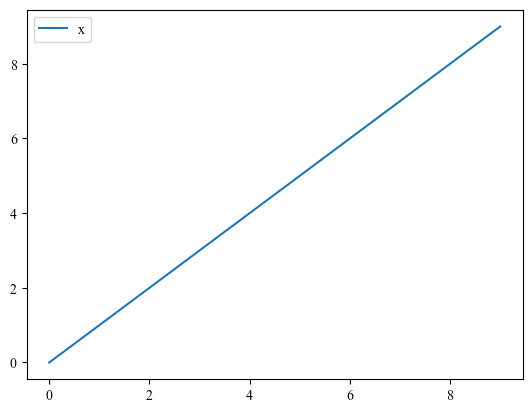

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
import matplotlib as mpl
from matplotlib import font_manager as fm

font_path = '../../times.ttf' # 或绝对路径 '/home/me/fonts/times.ttf'
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
font_name = prop.get_name()

mpl.rcParams['font.family'] = font_name
plt.plot(range(10),range(10),label='x')
plt.legend()

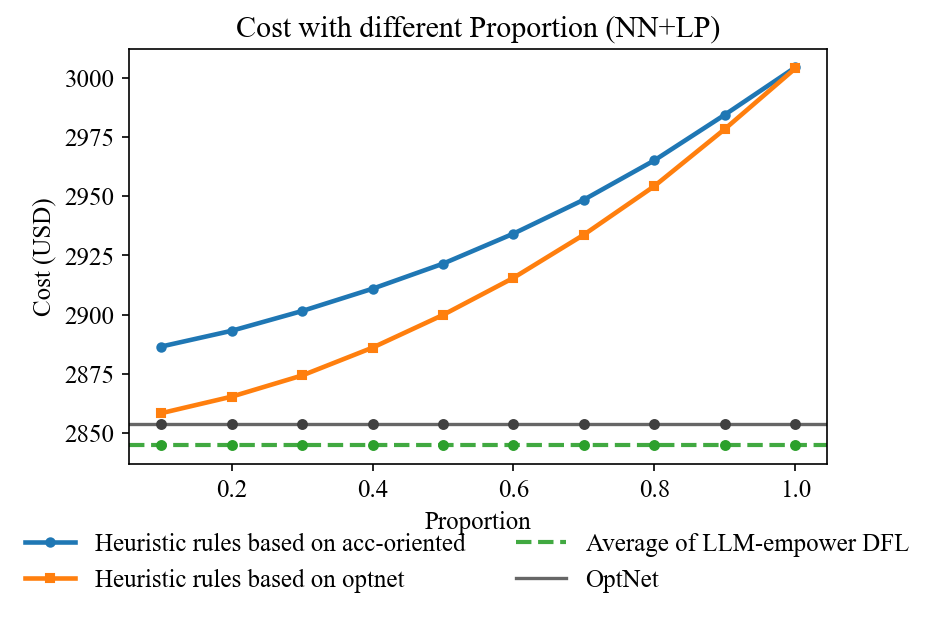

In [33]:
plt.rcParams['font.size'] = 12 
x = np.asarray(prop_list, dtype=float)
y_ft = np.asarray(fine_tuned_cost_lst, dtype=float)
y_ft_optnet = np.asarray(fine_tuned_cost_optnet_lst, dtype=float)

ds, qwen, llama = 2844.59, 2845.48, 2844.61
optnet = 2854.00
baseline_avg = (ds + qwen + llama) / 3.0

fig, ax = plt.subplots(figsize=(6, 4.2), dpi=150)

ax.plot(x, y_ft, lw=2.2, marker="o", ms=4, color="#1f77b4", label="Heuristic rules based on acc-oriented")
ax.plot(x, y_ft_optnet, lw=2.2, marker="s", ms=4, color="#ff7f0e", label="Heuristic rules based on optnet")

ax.axhline(baseline_avg, ls="--", lw=2.0, color="#2ca02c", alpha=0.9,
           label=f"Average of LLM-empower DFL")
ax.axhline(optnet, ls="-", lw=1.6, color="0.25", alpha=0.8,
           label=f"OptNet")

# 如果你想在水平线上也显示一些点，用 scatter（可选）
k = max(1, len(x)//8)
xm = x[::k]
ax.scatter(xm, np.full_like(xm, baseline_avg), s=18, color="#2ca02c", zorder=3)
ax.scatter(xm, np.full_like(xm, optnet), s=18, color="0.25", zorder=3)

ax.set_xlabel("Proportion")
ax.set_ylabel("Cost (USD)")
ax.set_title("Cost with different Proportion (NN+LP)")

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, fontsize=12,
           bbox_to_anchor=(0.5, -0.02))
fig.subplots_adjust(bottom=0.22)
plt.savefig('../../Figure/Heuristic_NN_LP.jpg',dpi=1000)
plt.show()